In [19]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [20]:
from stn_gpe import RosslerNetwork, load_yaml
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import os

In [21]:
path = os.path.join(project_root,'params/stn_gpe_params/params_I_ext.yaml') 
data = load_yaml(path)
omega =np.ones((data['N'],1))*data['omega']    


In [22]:
data

{'a': 0.2,
 'b': 0.2,
 'c': 5.7,
 'N': 100,
 'Iext': 1.75,
 'd': 0.5,
 'k': 0.5,
 'prob_active': 0.4,
 'omega': 0.8}

## Rossler Network

In [23]:
RN = RosslerNetwork(N = data['N'], 
                    a = data['a'],
                    b = data['b'], 
                    c = data['c'], 
                    d = data['d'], 
                    k = data['k'],
                    omega= omega, 
                    Iext=data['Iext'])

In [24]:
sol = RN.run()

## Phase portrait

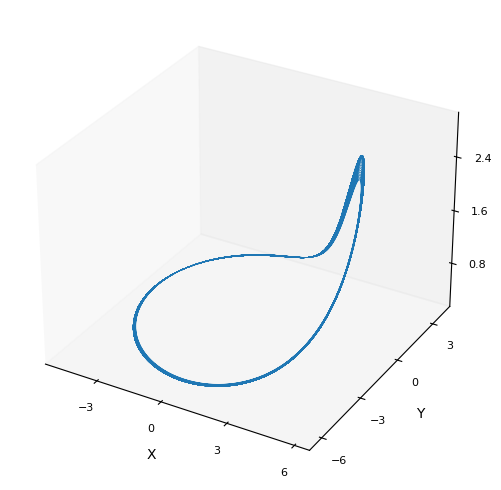

In [25]:
t_low = 200000
t_high = 50000*10
t = np.linspace(0, (t_high-t_low)/50000,t_high-t_low)

x_solved = np.array(sol.y[0,t_low:t_high]) 
y_solved = np.array(sol.y[data['N'],t_low:t_high]) 
z_solved = np.array(sol.y[2*data['N'],t_low:t_high]) 
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_solved, y_solved, z_solved, lw=0.5)
ax.grid(False)
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  
ax.zaxis.set_major_locator(MaxNLocator(nbins=4)) 
ax.tick_params(axis='x', labelsize=8)  
ax.tick_params(axis='y', labelsize=8)  
ax.tick_params(axis='z', labelsize=8)  
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z' ,labelpad=15)
# ax.set_frame_on(False)
plt.tight_layout()
plt.show()

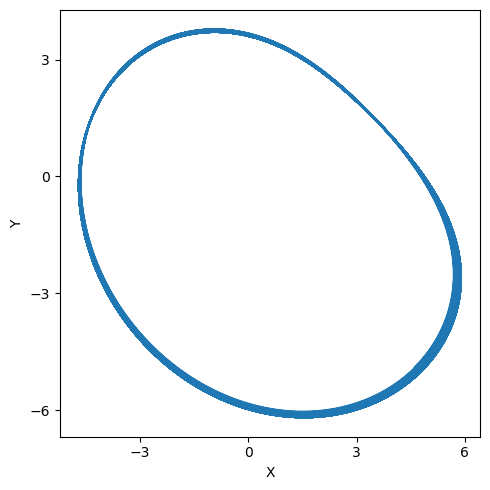

In [26]:
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111)
ax.plot(x_solved,y_solved)
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()

plt.show()

## Power spectrum

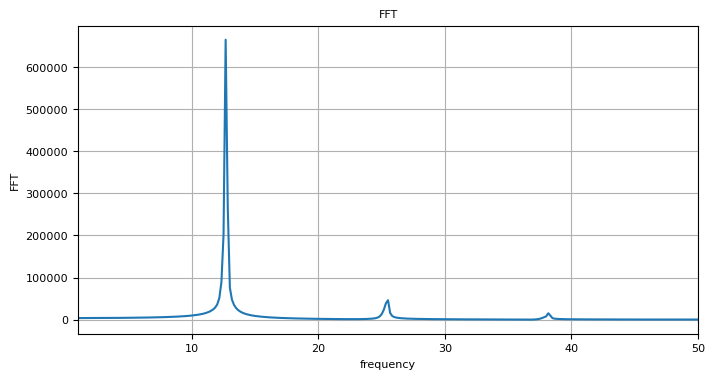

In [27]:
sampling_rate = 50000 #70000
fft_output = np.fft.fft(x_solved)
N_fft = len(fft_output)
n = np.arange(N_fft)
T = N_fft/sampling_rate
freq = n/T

plt.figure(figsize = (8,4))
plt.plot(freq, (np.abs(fft_output)))#/np.linalg.norm(np.abs(fft_output))))
plt.xlim(1,50)
plt.title('FFT',fontsize="8")
plt.xlabel('frequency',fontsize="8")
plt.ylabel('FFT',fontsize="8")
plt.xticks(fontsize="8")
plt.yticks(fontsize = '8')
plt.grid()

## Time series plot

In [28]:
t_low = 100000
t_high = 50000*10
t = np.linspace(0, (t_high-t_low)/50000,t_high-t_low)

In [29]:
x_vals = np.array(sol.y)[0:data['N'],:]
y_vals = np.array(sol.y)[data['N']:2*data['N'],:]
z_vals = np.array(sol.y)[2*data['N']:3*data['N'],:]

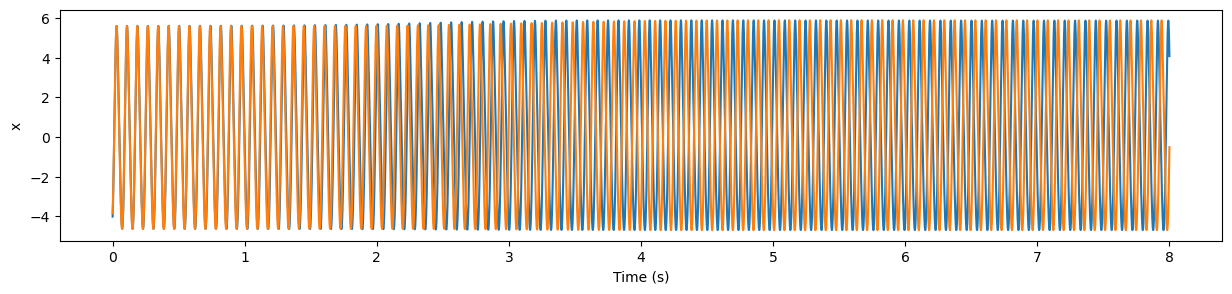

In [30]:
# t= np.linspace(0,2,100000)

plt.figure(figsize = (15,3))
plt.plot(t,np.array(sol.y)[0,t_low:t_high])
plt.plot(t,np.array(sol.y)[10,t_low:t_high])
# plt.plot(t,np.array(sol.y)[70,t_low:t_high])
plt.xlabel('Time (s)')
plt.ylabel('x')
# plt.savefig(data['folder_name']+'/'+data['file_name']+"_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()

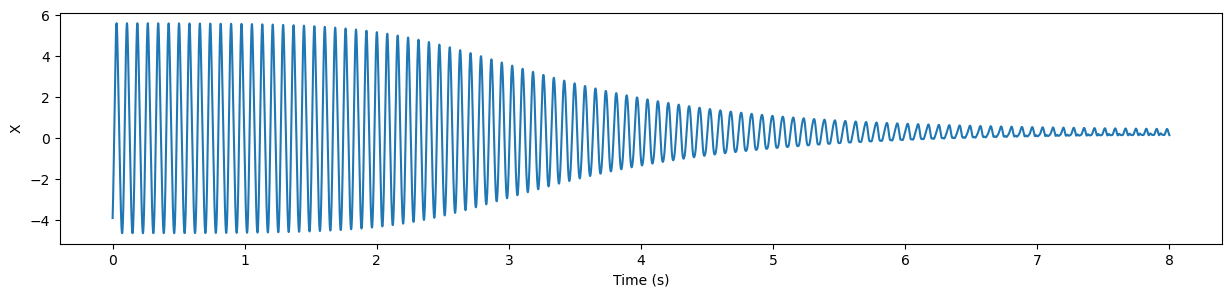

In [31]:
X_vals = np.mean(x_vals,0)
plt.figure(figsize = (15,3))
plt.plot(t,X_vals[t_low:t_high])
plt.xlabel('Time (s)')
plt.ylabel('X')
# plt.savefig(data['folder_name']+'/'+data['file_name']+"_X_mean.png", dpi=300, bbox_inches='tight')
plt.show()

## Feedback controller

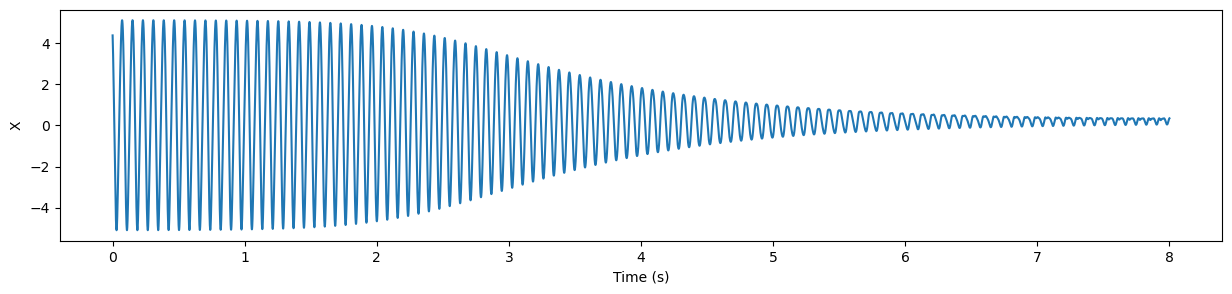

In [32]:
X_vals = np.mean(x_vals,0)
plt.figure(figsize = (15,3))
plt.plot(t,data['d']-X_vals[t_low:t_high])
plt.xlabel('Time (s)')
plt.ylabel('X')
plt.show()

## Correlation coeff


Avg corr: 0.09321899743237598


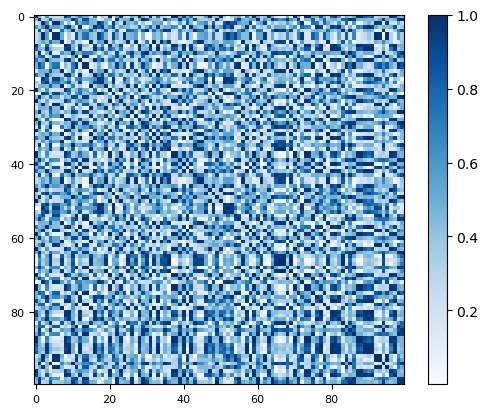

In [33]:
corr = np.corrcoef((x_vals))
avg_corr = np.mean(corr[np.triu_indices(4, k = 1)])
print(f'Avg corr: {avg_corr}')
plt.imshow(np.abs(corr), cmap='Blues')
cbar = plt.colorbar()
# cbar.mappable.set_clim(0.9999, 1.0) 
# cbar.set_ticks(np.linspace(0, 1.0, num=5))
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
# plt.savefig(data['folder_name']+'/'+data['file_name']+"_corr_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

## Variance

In [34]:
normalized_x_vals = (x_vals - np.min(x_vals))/(np.max(x_vals)-np.min(x_vals))
x_mean = np.mean(normalized_x_vals,0)
x_std = np.std(normalized_x_vals,0)
print(f'Mean variance across the x amplitude: {np.mean(x_std)}')

Mean variance across the x amplitude: 0.2639778828199825


Text(0, 0.5, 'x amplitude')

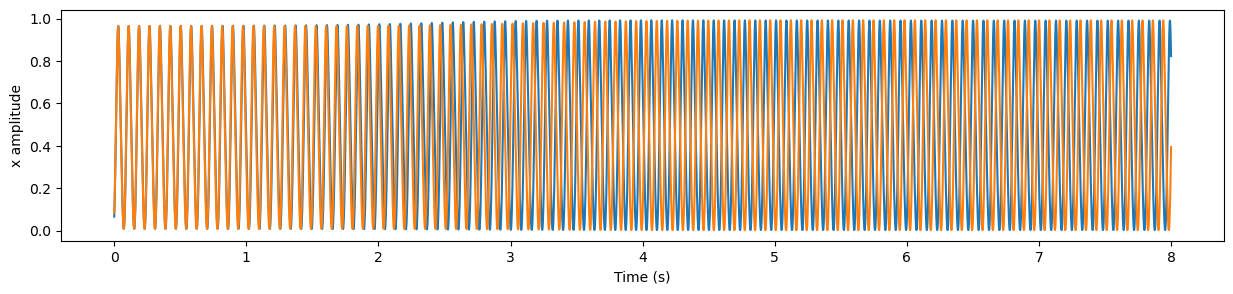

In [35]:
plt.figure(figsize = (15,3))
plt.plot(t,normalized_x_vals[0,t_low:t_high])
plt.plot(t,normalized_x_vals[10,t_low:t_high])
plt.xlabel('Time (s)')
plt.ylabel('x amplitude')

Text(0.5, 1.0, 'Mean')

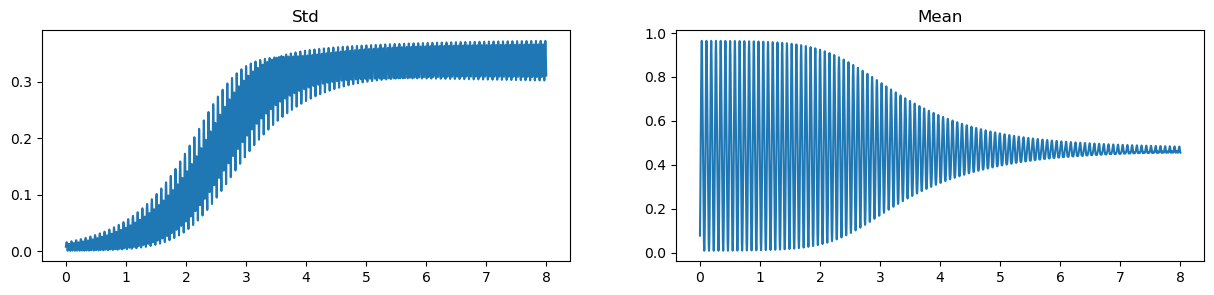

In [36]:
plt.figure(figsize = (15,3))
plt.subplot(121)
plt.plot(t,x_std[t_low:t_high])
plt.title('Std')
plt.subplot(122)
plt.plot(t,x_mean[t_low:t_high])
plt.title('Mean')